**Covid 19 Dataset Analysis**

In [ ]:
import pandas as pd

# Loading dataset
file_path = "Covid_19 Dataset.csv"
df = pd.read_csv(file_path)

In [ ]:
# --- Data Cleaning ---

# 1. Dropping unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [ ]:
# 2. Handling missing values
# Fill missing continent values with "Unknown"
df['continent'] = df['continent'].fillna("Unknown")

In [ ]:
# Filling numeric columns with 0
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

In [ ]:
# 3. Resetting index (optional for cleaner dataframe)
df = df.reset_index(drop=True)

In [ ]:
# 4. Converting 'day' and 'time' to datetime (optional)
df['day'] = pd.to_datetime(df['day'], errors='coerce')
df['time'] = pd.to_datetime(df['time'], errors='coerce')

In [ ]:
# Checking results
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   country          231 non-null    object             
 1   continent        231 non-null    object             
 2   population       231 non-null    float64            
 3   day              231 non-null    datetime64[ns]     
 4   time             231 non-null    datetime64[ns, UTC]
 5   active_cases     231 non-null    float64            
 6   critical_cases   231 non-null    float64            
 7   total_cases      231 non-null    int64              
 8   recovered_cases  231 non-null    float64            
 9   1M_pop_cases     231 non-null    float64            
 10  1M_pop_deaths    231 non-null    float64            
 11  total_deaths     231 non-null    float64            
 12  1M_pop_tests     231 non-null    float64            
 13  total_tests      231

**1.** **What are the top 10 countries with the highest total cases?**

In [ ]:
top_cases = df.sort_values(by="total_cases", ascending=False).head(10)
print(top_cases[["country", "total_cases"]])

     country  total_cases
220      USA    111820082
94     India     45035393
72    France     40138560
78   Germany     38828995
26    Brazil     38743918
171  S-Korea     34571873
104    Japan     33803572
101    Italy     26723249
217       UK     24910387
169   Russia     24124215


/tmp/ipython-input-2374361706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_cases", y="country", data=top_cases, palette="viridis")


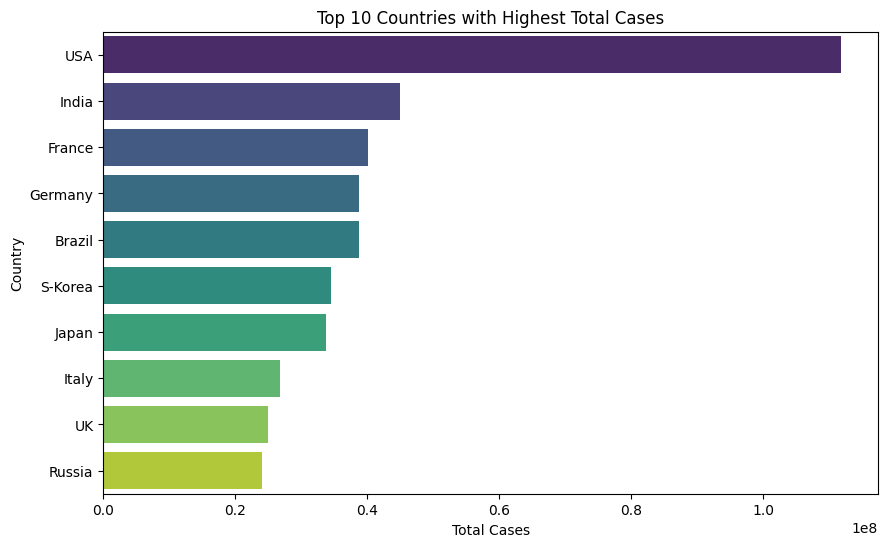

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_cases = df.sort_values(by="total_cases", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="total_cases", y="country", data=top_cases, palette="viridis")
plt.title("Top 10 Countries with Highest Total Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.show()

**2. What are the top 10 countries with the highest total deaths?**

In [ ]:
top_deaths = df.sort_values(by="total_deaths", ascending=False).head(10)
print(top_deaths[["country", "total_deaths"]])

     country  total_deaths
220      USA     1219487.0
26    Brazil      711380.0
94     India      533570.0
169   Russia      402756.0
132   Mexico      334958.0
217       UK      232112.0
162     Peru      222161.0
101    Italy      196487.0
78   Germany      183027.0
72    France      167642.0


/tmp/ipython-input-4057613790.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_deaths", y="country", data=top_deaths, palette="magma")


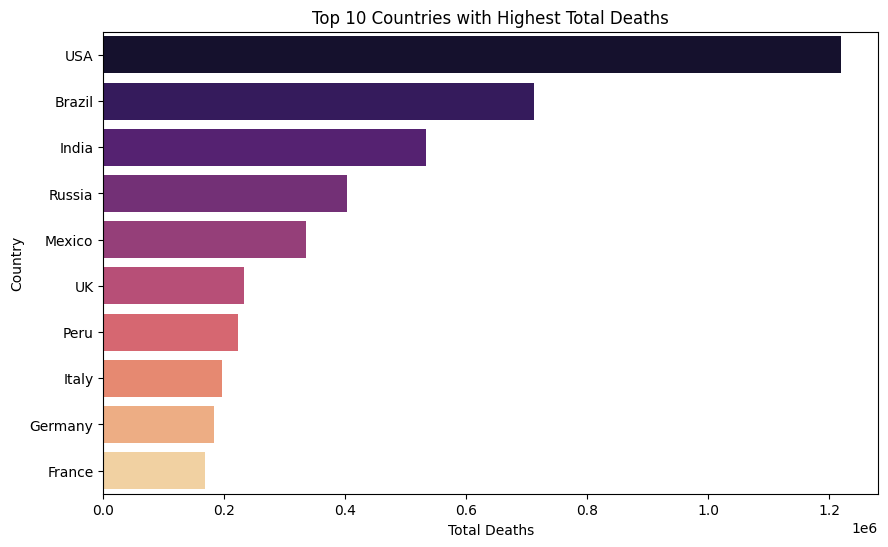

In [ ]:
top_deaths = df.sort_values(by="total_deaths", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="total_deaths", y="country", data=top_deaths, palette="magma")
plt.title("Top 10 Countries with Highest Total Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Country")
plt.show()

**3. Which continents have the highest number of cases?**

In [ ]:
continent_cases = df.groupby("continent")["total_cases"].sum().sort_values(ascending=False)
print(continent_cases)

continent
Europe           253406198
Asia             221500265
North-America    131889132
South-America     70200879
Oceania           14895771
Africa            12860924
Unknown                721
Name: total_cases, dtype: int64


/tmp/ipython-input-1448954095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="continent", y="total_cases", data=continent_cases, palette="Set2")


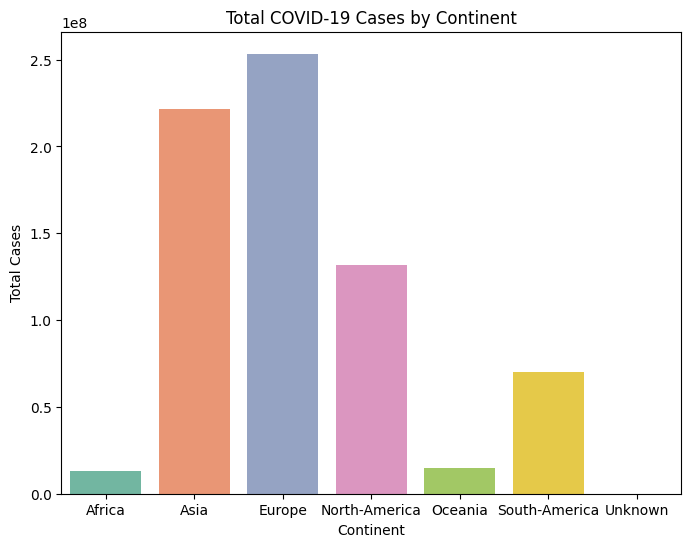

In [ ]:
continent_cases = df.groupby("continent")["total_cases"].sum().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x="continent", y="total_cases", data=continent_cases, palette="Set2")
plt.title("Total COVID-19 Cases by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Cases")
plt.show()

**4. Which continents have the highest case fatality rate (deaths / cases)?**

In [ ]:
df["fatality_rate"] = (df["total_deaths"] / df["total_cases"]) * 100
continent_fatality = df.groupby("continent")["fatality_rate"].mean().sort_values(ascending=False)
print(continent_fatality)

continent
Unknown          12.024032
Africa            1.905366
South-America     1.766192
Asia              1.359778
North-America     1.078474
Europe            0.915010
Oceania           0.338738
Name: fatality_rate, dtype: float64


/tmp/ipython-input-493708105.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="continent", y="fatality_rate", data=continent_fatality, palette="coolwarm")


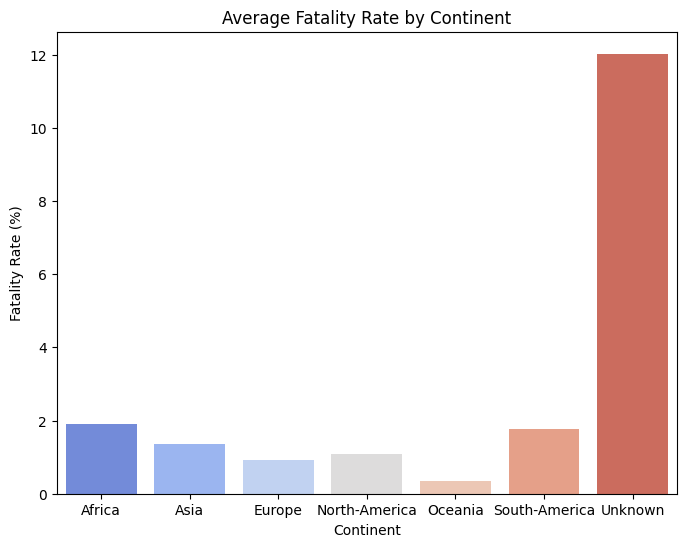

In [ ]:
df["fatality_rate"] = (df["total_deaths"] / df["total_cases"]) * 100
continent_fatality = df.groupby("continent")["fatality_rate"].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x="continent", y="fatality_rate", data=continent_fatality, palette="coolwarm")
plt.title("Average Fatality Rate by Continent")
plt.xlabel("Continent")
plt.ylabel("Fatality Rate (%)")
plt.show()

**5. Which countries have the highest testing per million population?**

In [ ]:
top_testing = df.sort_values(by="1M_pop_tests", ascending=False).head(10)
print(top_testing[["country", "1M_pop_tests"]])

              country  1M_pop_tests
11            Austria    23302116.0
53            Denmark    22165247.0
215               UAE    19910389.0
21            Bermuda    16622128.0
80          Gibraltar    15852213.0
68     Faeroe-Islands    15802409.0
213  Turks-and-Caicos    15520193.0
193             Spain    10082298.0
91          Hong-Kong    10011143.0
81             Greece     9909078.0


/tmp/ipython-input-2701554365.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="1M_pop_tests", y="country", data=top_testing, palette="Blues_r")


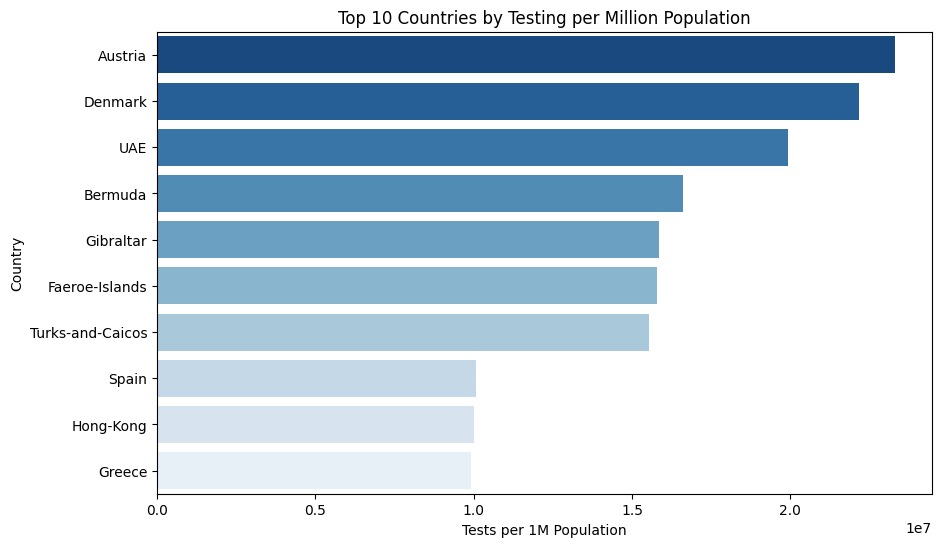

In [ ]:
top_testing = df.sort_values(by="1M_pop_tests", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="1M_pop_tests", y="country", data=top_testing, palette="Blues_r")
plt.title("Top 10 Countries by Testing per Million Population")
plt.xlabel("Tests per 1M Population")
plt.ylabel("Country")
plt.show()

**6. What is the correlation between population and total cases?**

In [ ]:
correlation = df["population"].corr(df["total_cases"])
print("Correlation between population and total cases:", correlation)

Correlation between population and total cases: 0.36815627636771064


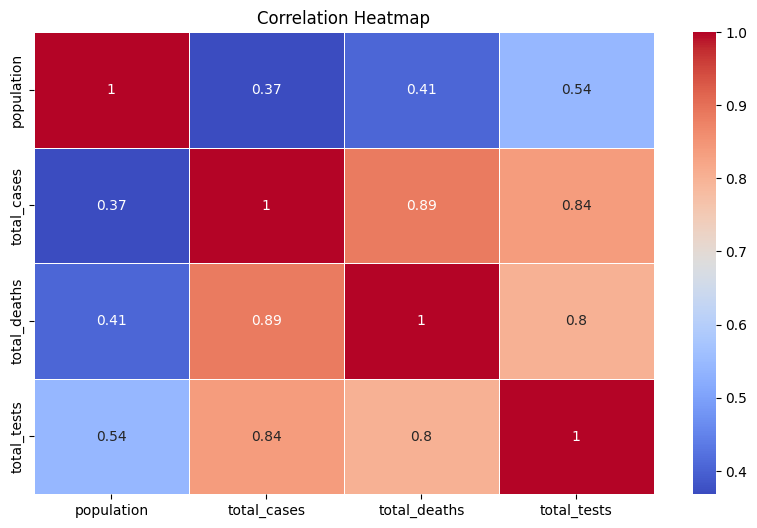

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[["population","total_cases","total_deaths","total_tests"]].corr(),
            annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**7. What is the recovery rate across countries?**

In [ ]:
df["recovery_rate"] = (df["recovered_cases"] / df["total_cases"]) * 100
top_recovery = df.sort_values(by="recovery_rate", ascending=False).head(10)
print(top_recovery[["country", "recovery_rate"]])

              country  recovery_rate
69   Falkland-Islands     100.000000
223      Vatican-City     100.000000
58               DPRK      99.998450
185         Singapore      99.932671
171           S-Korea      99.896060
127  Marshall-Islands      99.894659
166             Qatar      99.837325
202            Taiwan      99.814432
51             Cyprus      99.799592
157             Palau      99.777424


/tmp/ipython-input-3676070286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="recovery_rate", y="country", data=top_recovery, palette="Greens")


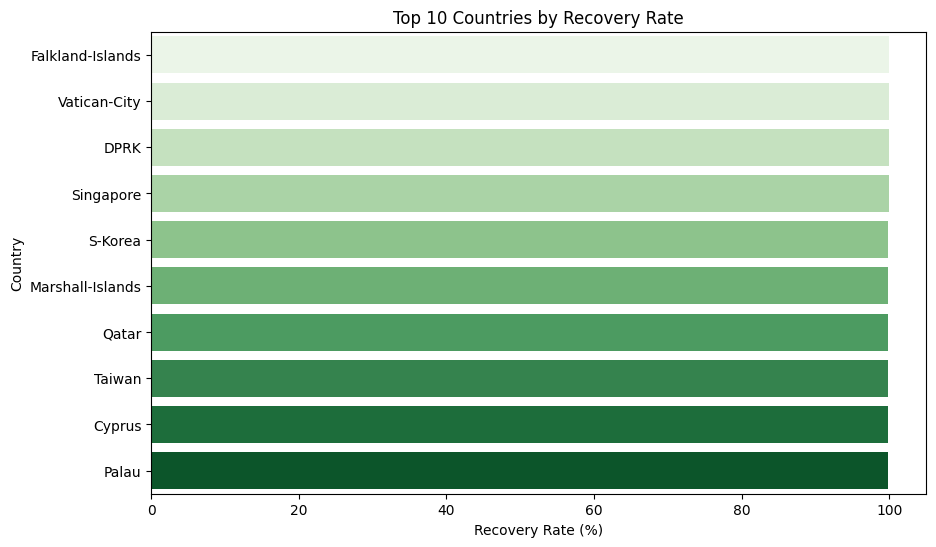

In [ ]:
df["recovery_rate"] = (df["recovered_cases"] / df["total_cases"]) * 100
top_recovery = df.sort_values(by="recovery_rate", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="recovery_rate", y="country", data=top_recovery, palette="Greens")
plt.title("Top 10 Countries by Recovery Rate")
plt.xlabel("Recovery Rate (%)")
plt.ylabel("Country")
plt.show()

**8. How do cases, deaths, and recoveries vary by continent?**

In [ ]:
summary = df.groupby("continent")[["total_cases", "total_deaths", "recovered_cases"]].sum()
print(summary)

               total_cases  total_deaths  recovered_cases
continent                                                
Africa            12860924      258892.0        9211514.0
Asia             221500265     1553662.0      108524029.0
Europe           253406198     2101824.0      235797174.0
North-America    131889132     1695941.0      126483239.0
Oceania           14895771       33015.0       14615509.0
South-America     70200879     1367332.0       65935495.0
Unknown                721          15.0            706.0


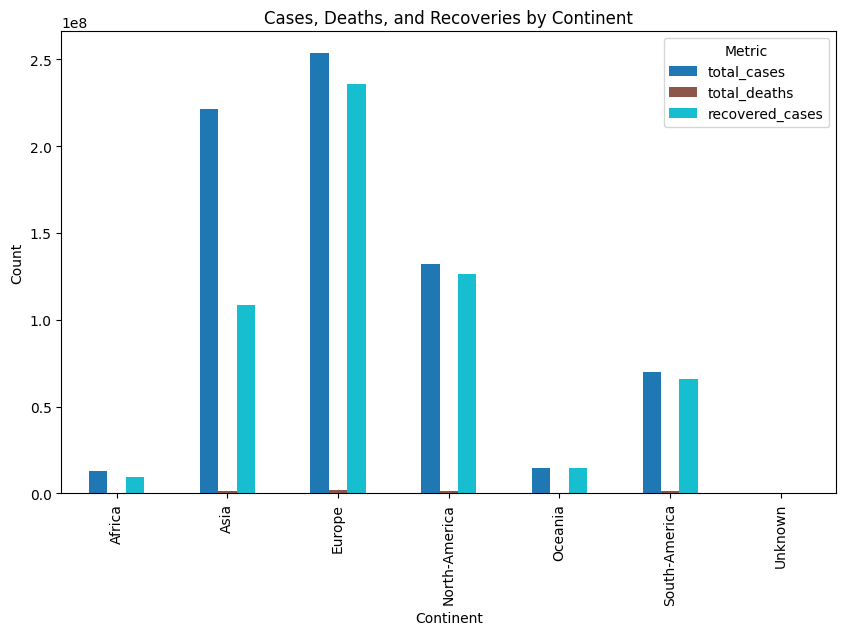

In [ ]:
summary = df.groupby("continent")[["total_cases", "total_deaths", "recovered_cases"]].sum().reset_index()

summary.plot(x="continent", kind="bar", figsize=(10,6), stacked=False, colormap="tab10")
plt.title("Cases, Deaths, and Recoveries by Continent")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.legend(title="Metric")
plt.show()